# F78DS Coursework 2
- Student Details
  - Student Name: Qing Hao, Too
  - Student ID: H00467830
  - Course: F78DS - Data Science Life Cycle
  - Assignment: Coursework 2
  - Due Date: 7th April 2026, 5:00PM (M'sia)

# Introduction

This coursework focuses on building a supervised learning model to predict essay scores based on linguistic features. The dataset provides numerical attributes extracted from essays, and the target is a score between 1 and 6. The task is to train a model that can generalise to unseen essays, with performance measured using Quadratic Weighted Kappa (QWK).

The notebook is structured as follows:
- Data inspection and cleaning
- Feature engineering and train‑test split
- Building and evaluating classification models (Decision Tree)
- Exploring alternative models (Random Forest, CatBoost)
- Generating predictions for the Kaggle submission

Below here, we import libraries required for this coursework, that includes
1. `pandas` for dataset reading and manipulation
2. `matplotlib.pyplot`, `seaborn` and `plotly` for data visualisation
3. `numpy` for mathematical functions
4. `sklearn` and `catboost` for machine learning features

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score, make_scorer

from catboost import CatBoostClassifier

we start by reading the essay features dataset, `init` variable is used since it is the initial DataFrame we have.

In [2]:
init = pd.read_csv('data/F78DS-Essay-Features.csv')

To ensure that the file has been read properly, we can first check whether the resulting DataFrame has the same number of rows and columns as the original csv file

In [3]:
init.shape

(1332, 19)

In [4]:
init.columns

Index(['essayid', 'chars', 'words', 'commas', 'apostrophes', 'punctuations',
       'avg_word_length', 'sentences', 'questions', 'avg_word_sentence', 'POS',
       'POS/total_words', 'prompt_words', 'prompt_words/total_words',
       'synonym_words', 'synonym_words/total_words', 'unstemmed', 'stemmed',
       'score'],
      dtype='str')

Via the cell below, we can _see_ there exists outliers everywhere. It could become dangerous, as it begs the question, "To remove or not to remove the outliers".

In [5]:
init.dtypes

essayid                        int64
chars                          int64
words                          int64
commas                         int64
apostrophes                    int64
punctuations                   int64
avg_word_length              float64
sentences                      int64
questions                      int64
avg_word_sentence            float64
POS                          float64
POS/total_words              float64
prompt_words                   int64
prompt_words/total_words     float64
synonym_words                  int64
synonym_words/total_words    float64
unstemmed                      int64
stemmed                        int64
score                          int64
dtype: object

The output shows that there are `1332` rows and `19` columns. Comparing this with the original `.csv` file, which also has `1332` rows (excluding the first row which is used as a header and is thus not counted as a row in the DataFrame) and `19` columns, we can see that the resulting DataFrame has the same number of rows and columns as the original file.

Next we can display the first and last 5 rows of the `init` DataFrame to check whether the contents of the cells have been read properly

In [6]:
init.head()

,essayid,chars,words,commas,apostrophes,punctuations,avg_word_length,sentences,questions,avg_word_sentence,POS,POS/total_words,prompt_words,prompt_words/total_words,synonym_words,synonym_words/total_words,unstemmed,stemmed,score
0,1457,2153,426,14,6,0,5.053991,16,0,26.625000,423.995272,0.995294,207,0.485915,105,0.246479,424,412,4
1,503,1480,292,9,7,0,5.068493,11,0,26.545455,290.993103,0.996552,148,0.506849,77,0.263699,356,345,4
2,253,3964,849,19,26,1,4.669022,49,2,17.326531,843.990544,0.994100,285,0.335689,130,0.153121,750,750,4
3,107,988,210,8,7,0,4.704762,12,0,17.500000,207.653784,0.988828,112,0.533333,62,0.295238,217,209,3
4,1450,3139,600,13,8,0,5.231667,24,1,25.000000,594.652150,0.991087,255,0.425000,165,0.275000,702,677,4


In [7]:
init.tail()

,essayid,chars,words,commas,apostrophes,punctuations,avg_word_length,sentences,questions,avg_word_sentence,POS,POS/total_words,prompt_words,prompt_words/total_words,synonym_words,synonym_words/total_words,unstemmed,stemmed,score
1327,1151,2404,467,16,10,0,5.147752,22,0,21.227273,462.987069,0.991407,200,0.428266,113,0.241970,529,519,4
1328,1015,1182,241,0,14,0,4.904564,16,0,15.062500,238.655462,0.990272,94,0.390041,67,0.278008,293,283,3
1329,1345,1814,363,5,11,0,4.997245,13,3,27.923077,362.329640,0.998153,170,0.468320,107,0.294766,427,415,3
1330,344,1427,287,5,8,0,4.972125,13,1,22.076923,284.657277,0.991837,144,0.501742,83,0.289199,323,312,3
1331,1077,2806,542,24,6,0,5.177122,22,3,24.636364,538.988889,0.994444,284,0.523985,155,0.285978,596,575,4


In [8]:
init.describe()

,essayid,chars,words,commas,apostrophes,punctuations,avg_word_length,sentences,questions,avg_word_sentence,POS,POS/total_words,prompt_words,prompt_words/total_words,synonym_words,synonym_words/total_words,unstemmed,stemmed,score
count,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000
mean,905.27027,2101.745495,424.485736,14.667417,8.141141,0.47973,4.939762,19.704204,1.222973,23.884687,420.596542,0.989935,198.913664,0.469164,110.16967,0.263846,468.987988,455.507508,3.427177
std,526.68760,865.963750,171.873730,10.920781,6.124520,1.27168,0.231071,19.202731,1.847446,11.160020,170.985111,0.007308,82.729266,0.052466,43.96192,0.038870,159.447449,155.751220,0.774275
min,0.00000,169.000000,36.000000,0.000000,2.000000,0.00000,2.231322,0.000000,0.000000,1.084112,35.647059,0.924771,14.000000,0.288889,11.00000,0.027299,48.000000,50.000000,1.000000
25%,442.75000,1527.250000,310.000000,7.000000,4.000000,0.00000,4.791679,13.000000,0.000000,19.142857,305.406284,0.987758,144.000000,0.435709,81.00000,0.238423,361.000000,350.750000,3.000000
50%,914.50000,2029.500000,411.000000,13.000000,6.000000,0.00000,4.946059,18.000000,1.000000,22.030331,406.982869,0.991572,193.000000,0.465852,107.50000,0.262872,463.000000,448.000000,3.000000
75%,1369.75000,2613.500000,525.000000,21.000000,11.000000,0.00000,5.092938,24.000000,2.000000,26.048234,520.739458,0.994425,246.000000,0.500000,134.00000,0.288277,581.000000,561.250000,4.000000
max,1799.00000,6142.000000,1170.000000,72.000000,51.000000,26.00000,5.681429,642.000000,17.000000,303.000000,1158.984563,1.000000,669.000000,0.961207,355.00000,0.465517,750.000000,750.000000,6.000000


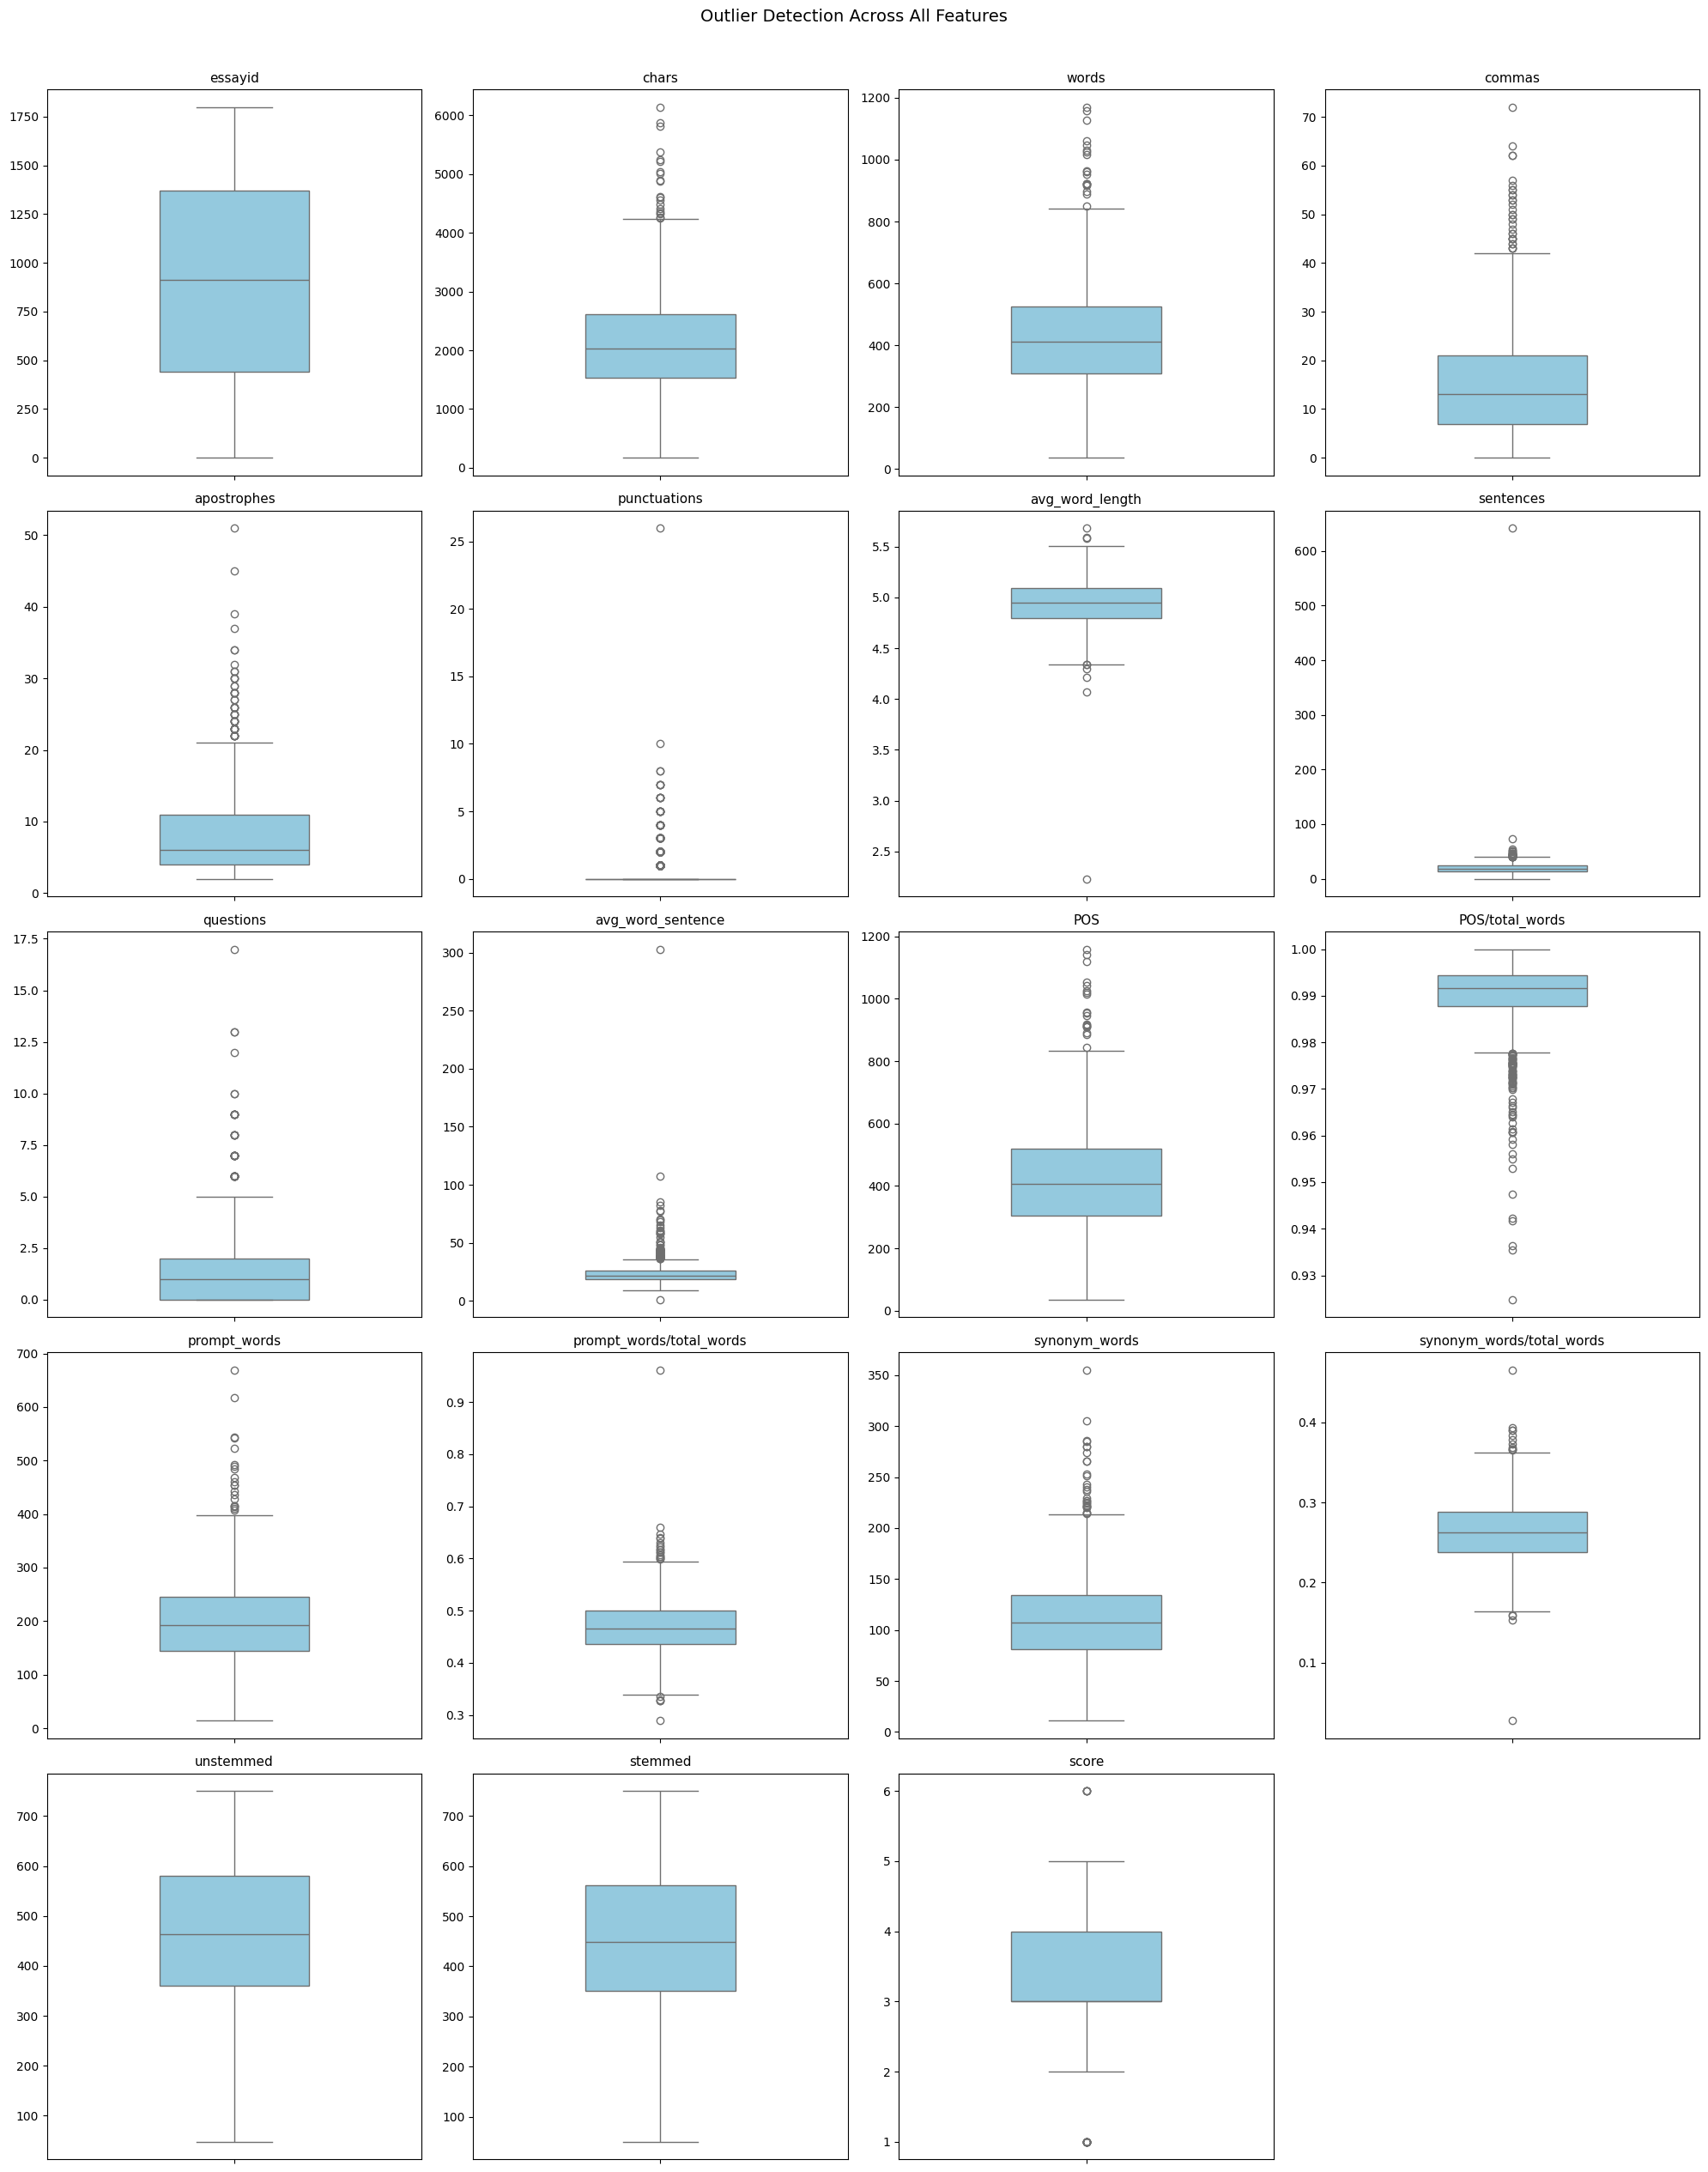

In [9]:
# Visualise outliers using boxplot
def plot_individual_boxplots(df):
    num_cols_numeric = len(df.select_dtypes(include=['number']).columns)
    ncols = 4  # 4 plots per row
    nrows = int(np.ceil(num_cols_numeric / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = axes.flatten()  # flatten for easy indexing

    for i, col in enumerate(df.select_dtypes(include=['number']).columns):
        sns.boxplot(y=df[col], ax=axes[i], color="skyblue", width=0.4)
        axes[i].set_title(f'{col}', fontsize=11)
        axes[i].set_ylabel('')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Outlier Detection Across All Features', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

plot_individual_boxplots(init)

To confirm the dataset is in Tidy Data format, we verify:
- Each variable forms a column
- Each observation forms a row
- No missing values, duplicate rows, or invalid entries

In [10]:
# Tidy Data checks
print("Missing values per column:")
print(init.isnull().sum())
print(f"\nDuplicate rows: {init.duplicated().sum()}")
print(f"\nScore distribution:\n{init['score'].value_counts().sort_index()}")

Missing values per column:
essayid                      0
chars                        0
words                        0
commas                       0
apostrophes                  0
punctuations                 0
avg_word_length              0
sentences                    0
questions                    0
avg_word_sentence            0
POS                          0
POS/total_words              0
prompt_words                 0
prompt_words/total_words     0
synonym_words                0
synonym_words/total_words    0
unstemmed                    0
stemmed                      0
score                        0
dtype: int64

Duplicate rows: 0

Score distribution:
score
1     18
2    110
3    557
4    583
5     60
6      4
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_4876\2098651091.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=init, order=range(1, 7), palette='Blues_d')


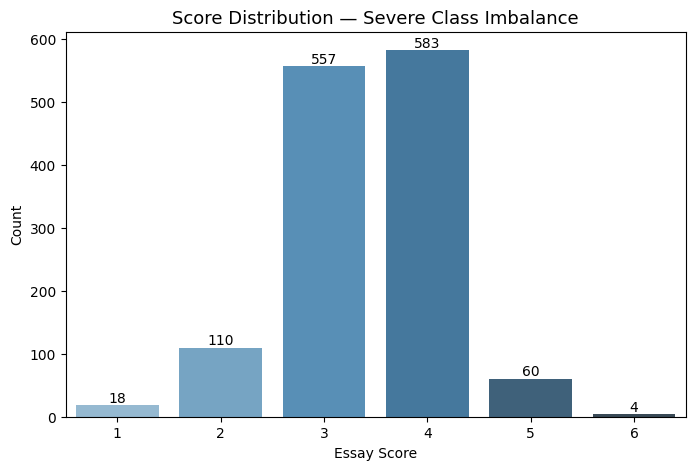

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(x='score', data=init, order=range(1, 7), palette='Blues_d')
plt.title('Score Distribution — Severe Class Imbalance', fontsize=13)
plt.xlabel('Essay Score')
plt.ylabel('Count')
for i, count in enumerate(init['score'].value_counts().sort_index()):
    plt.text(i, count + 5, str(count), ha='center', fontsize=10)
plt.show()

While we conclude our data exploration, we will take our chance to create two functions `plot_cm()` and `plot_hm()` which aims to plot the Confusion matrix as well as the Heatmap respectively. Placing it here allows us to use function in a reproducible way.

In [36]:
def plot_cm(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(y_test.unique())  # dynamic
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Score')
    plt.ylabel('Actual Score')
    plt.title('Confusion Matrix')
    plt.show()
    
def plot_hm(df):
    corr = df.corr()

    fig = px.imshow(corr, 
                    text_auto = True, 
                    aspect = "auto",
                    color_continuous_scale = 'RdBu_r',
                    zmin = -1, zmax = 1)

    fig.update_layout(title = 'Correlation Heatmap',
                    width = 1000,
                    height = 800)
    fig.show()

In [12]:
df = init.copy()

# Part 1: Supervised Learning

## What supervised learning is
In Supervised Learning, we are essentially providing the computer with an "answer key." The model learns by looking at input data (features) and comparing its guesses against the known correct outcomes (labels).

### Labeled Data
This refers to a dataset where the target output is already known. In our case, the score (1–6) is the label. Because we have these scores for previous essays, we can "supervise" the model’s training by showing it an essay's characteristics and telling it, "This specific combination of words and punctuation equals a score of 5."

### Training vs Test Datasets
- **Training Set**: This is the "study guide." The model uses this data to find patterns and correlations between essay features and the score.
- **Test Set**: This is the "final exam." We hide the labels from the model and ask it to predict the scores. We then compare its predictions to the actual labels to see how well it actually learned (instead of just memorizing the training data).

## Separating Features ($X$) and Label ($y$)

We need to isolate the target we want to predict from the data we use to make that prediction. We also remove the `essayid` because a random ID number has no statistical relationship with how "good" an essay is—keeping it would just confuse the model.

In [13]:
# 'score' is our label (y)
y = df['score']

# Everything else except 'essayid' and 'score' are our features (X)
X = df.drop(columns = ['essayid', 'score'])

## Feature Engineering & Selection
To improve performance, we shouldn't just throw raw numbers at the model. We want features that capture the quality of writing.

- **Dropping Redundancy**: `chars` and `words` are usually highly correlated. We might keep `words` as it’s a more standard metric for essay length.
- **Creating Ratios**: Raw counts can be misleading. A long essay will naturally have more commas. A better feature might be `comma_density` or `avg_words_per_sentence` (average sentence length).
- **Selection**: We keep `prompt_words` and `synonym_words` as they are strong indicators of vocabulary richness and topical relevance.

The following ideas are applied via the cell below.

In [14]:
def feature_engineer(df):
    df = df.copy()
    eps = 1e-6
    
    df['avg_word_length'] = df['chars'] / (df['words'] + eps)
    df['comma_density'] = df['commas'] / (df['words'] + eps)
    df['question_density'] = df['questions'] / (df['sentences'] + eps)
    df['avg_words_per_sentence'] = df['words'] / (df['sentences'] + eps)
    df['stemmed_ratio'] = df['stemmed'] / (df['stemmed'] + df['unstemmed'] + eps)
    
    # Add interaction features (helps trees find patterns with less depth)
    df['vocabulary_richness'] = df['avg_word_length'] * df['stemmed_ratio']
    df['topic_focus'] = df['prompt_words/total_words'] * df['synonym_words'] / (df['words'] + eps)
    
    df = df.drop(columns = ['chars'])
    
    return df

X = feature_engineer(X)

For tree‑based models, adding informative engineered features (densities, ratios, interactions) typically improves performance without overfitting, as trees automatically ignore irrelevant features. However, highly redundant features like `chars` were dropped to reduce computational cost without losing predictive power.

In [15]:
plot_hm(X)

## Splitting the Data (`train_test_split`)
We use `sklearn` to shuffle and carve out a portion of our data for testing.

**Explanation of Parameters**
- `test_size = 0.2`: This allocates 20% of the data to the test set and 80% to the training set. This is a standard "Pareto-ish" split (For special interest, look up to **The Pareto Principle, or 80/20 Principle**).

- `random_state = 42`: Machine learning involves shuffling. Setting a "seed" (like 42) ensures that every time you run the code, you get the same shuffle. This makes your results reproducible.

- `stratify = y` (The Sampling Method): This is the most critical part for your project. If 50% of your essays are scored "3", but only 5% are scored "6", a random split might accidentally put all the "6s" in the training set. Stratified sampling ensures that the training and test sets have the same proportion of each score as the original dataset. It prevents the model from being tested on a distribution it didn't actually learn from.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 42, # ensures reproducible results across runs
    stratify = y
)

# Part 2: Classification

## Binary vs. Multi-class Classification

Classification tasks are defined by the number of categories (or "buckets") we're sorting data into:

- **Binary classification** – Two choices (yes/no, spam/not spam, pass/fail). The model typically predicts a probability for the "positive" class.
- **Multi‑class classification** – Three or more distinct categories. In this coursework, we have six possible scores (1 through 6), making it a multi‑class problem.

## Normalisation / Standardisation – Do We Need It?

Normalisation (scaling) transforms numerical features to a common range. There are wwo common methods used, notably:

- **Standardisation (`StandardScaler`)** – centres data to mean 0 with unit variance:  
  $$z = \frac{x - \mu}{\sigma}$$

- **Min‑Max Normalisation (`MinMaxScaler`)** – scales to a fixed interval, usually [0, 1]:  
  $$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**Why scale?**  
Algorithms that rely on distances (k‑NN, SVM, k‑means) or gradients (neural networks, logistic regression) are sensitive to feature magnitudes. Without scaling, a feature with a large range (e.g., `chars` 169 - 6142) would dominate a feature with a small range (e.g., `questions` 0 - 17), leading to biased models and slower convergence.

**Do we need it here?**  
**No.** Decision trees and tree‑based ensembles (Random Forest, CatBoost) are **scale‑invariant**. They split nodes by comparing feature values to thresholds; the absolute magnitude does not affect the split. Therefore we skip scaling – it would not improve performance and would only add unnecessary complexity.

The cell below checks the normality of the dataset we have, since we are dealing with decision tree, we leave it as is without direct modification to the dataset.

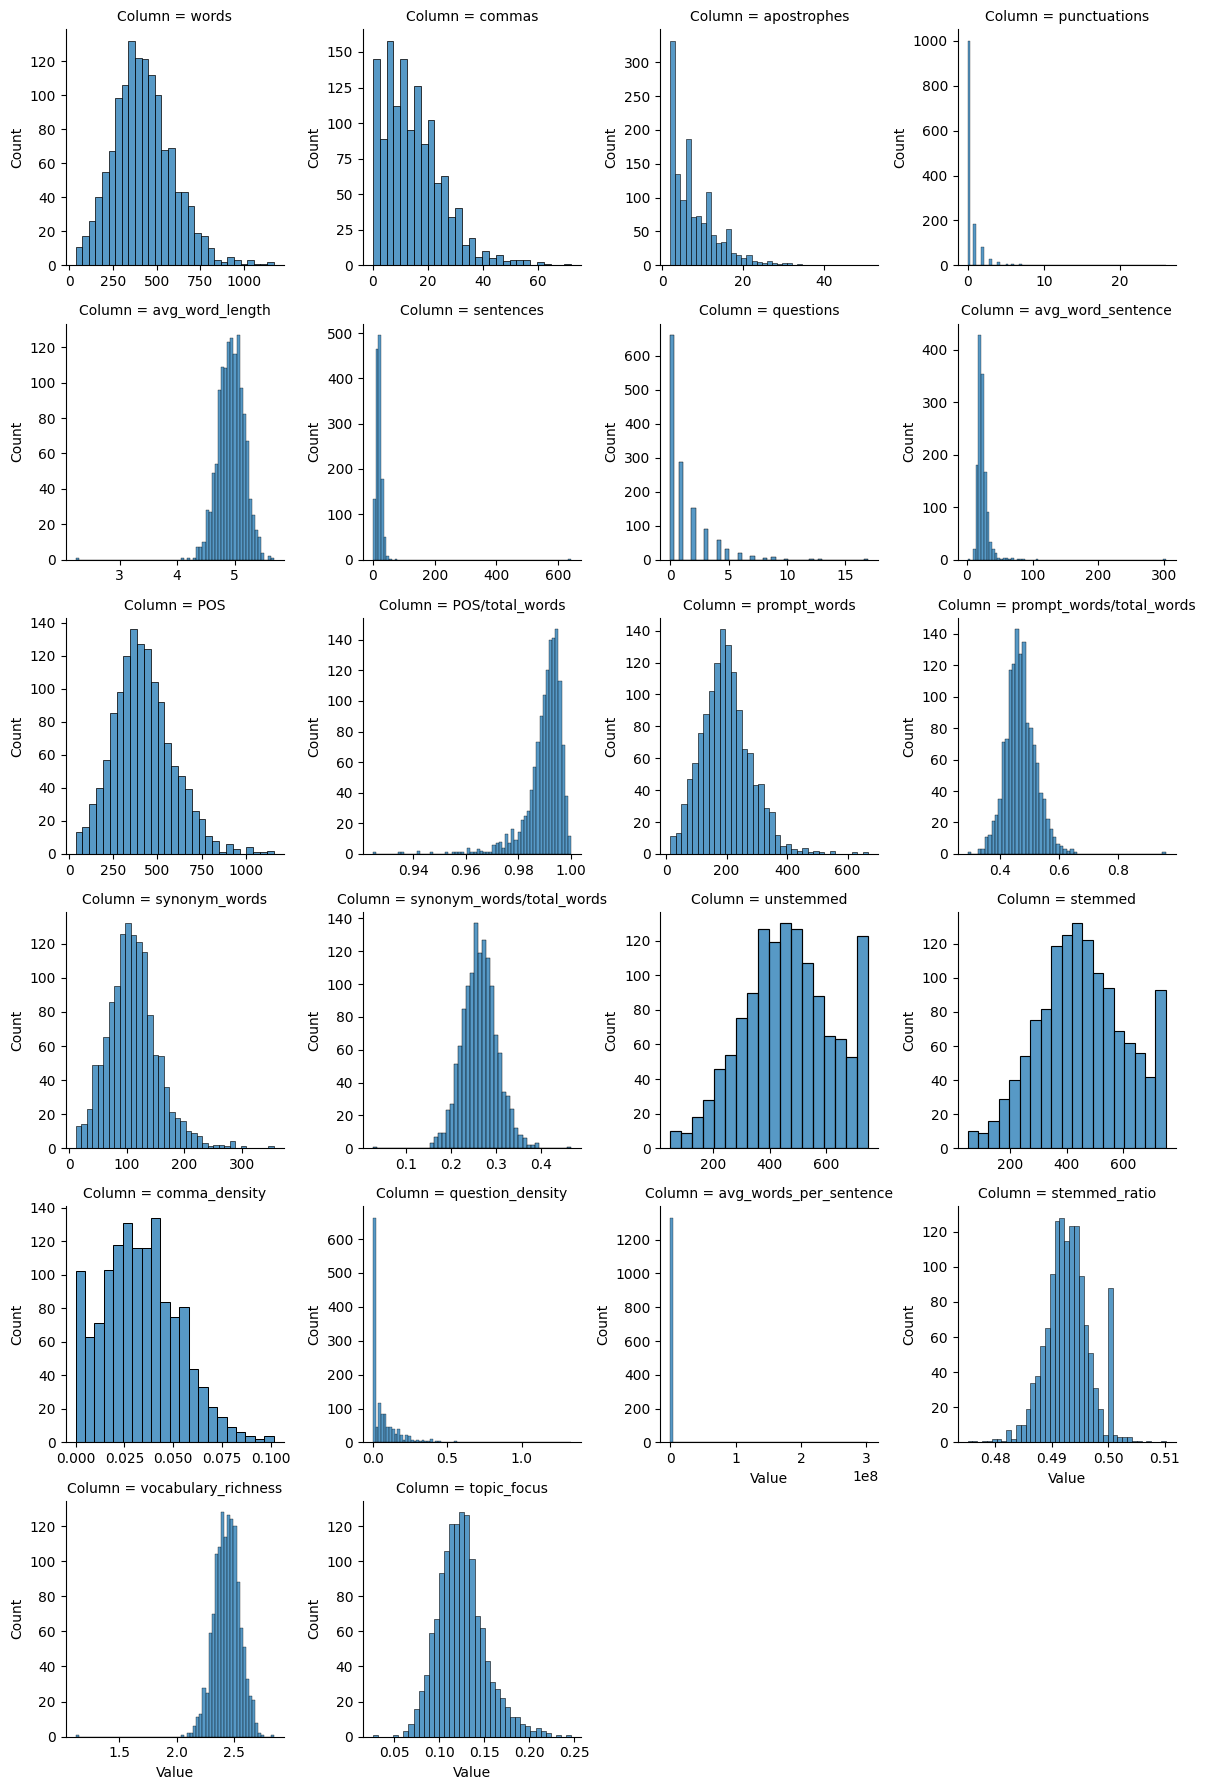

In [17]:
df_melted = X.melt(var_name = 'Column', value_name = 'Value')
g = sns.FacetGrid(df_melted, col = 'Column', col_wrap = 4, sharex = False, sharey = False)
g.map(sns.histplot, 'Value')
plt.tight_layout()
plt.show()

## Description of the Decision Tree Model

The model used is a `DecisionTreeClassifier` from the `sklearn` library. A Decision Tree is a non-parametric supervised learning algorithm that performs classification by breaking down a dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed.

## Hyperparameter Tuning and Justification (Including Class Imbalance)

Hyperparameter tuning balances the **bias‑variance tradeoff**. Using a **grid search with 5‑fold stratified cross‑validation**, I explored combinations for the Decision Tree classifier:

| Hyperparameter | Values Tuned | Optimal Value |
|---|---|---|
| `max_depth` | [5, 10, 15, 20, None] | **5** |
| `min_samples_split` | [10, 20, 30, 50] | **10** |
| `min_samples_leaf` | [5, 10, 20] | **10** |
| `criterion` | ['gini', 'entropy'] | **'gini'** |
| `class_weight` | ['balanced', None] | **None** |

### Why These Values – The Imbalance Problem

**Critical issue:** The dataset has severe class imbalance. In the training set (after `train_test_split` with stratification):
- Score 1: only **8** essays
- Score 6: only **1** essay
- Scores 3 and 4: together ~75% of the data

**`max_depth = 5`**  
A depth of 5 allows the tree to learn meaningful hierarchies without overfitting. Deeper trees (10+) overfit to the majority classes while still failing on minority classes (validation accuracy plateaued).

**`min_samples_split = 10` and `min_samples_leaf = 10`**  
These values are **deliberately high** to prevent the tree from creating leaves for tiny, noisy groups. However, **this choice explains why the model completely fails on scores 1, 5, and 6** (see confusion matrix). With only 8 or fewer training samples for these scores, the tree never reaches the minimum samples required to consider a split for those classes – it defaults to the majority classes (3 and 4). This is a known tradeoff: we sacrificed minority class recall to avoid overfitting the majority.

**`criterion = 'gini'`**  
Gini impurity is computationally faster and performed marginally better than entropy in cross‑validation.

**`class_weight = None`**  
Using `'balanced'` over‑compensated for the tiny minority classes, causing the model to predict them too often (e.g., predicting score 6 for many score‑4 essays), which hurt overall QWK. The chosen `min_samples_split` already forces the tree to be conservative.

**Cross‑validation used:** During hyperparameter tuning, I used `StratifiedKFold` with 5 splits. This ensures each fold maintains the same proportion of scores 1–6 as the original dataset, giving more reliable performance estimates and helping to avoid overfitting to a particular train/test split.

In [19]:
# Create a custom scorer for QWK
qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Define the parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

# Set up GridSearchCV with 5‑fold stratified cross‑validation
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=qwk_scorer,  # Optimise for QWK instead of accuracy
    n_jobs=1, 
    verbose=1
)

# Fit on the training data
grid_dt.fit(X_train, y_train)

# Automatically extract the best model (no manual copy-pasting needed!)
dt_model = grid_dt.best_estimator_

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Output results
print("-" * 50)
print("Best parameters found:", grid_dt.best_params_)
print("Best cross-validation QWK:", grid_dt.best_score_)
print("-" * 50)
print(f"Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Decision Tree Test QWK: {cohen_kappa_score(y_test, y_pred_dt, weights='quadratic'):.4f}")
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


--------------------------------------------------
Best parameters found: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best cross-validation QWK: 0.6418265029807333
--------------------------------------------------
Decision Tree Test Accuracy: 0.6592
Decision Tree Test QWK: 0.6068

Detailed Classification Report:

              precision    recall  f1-score   support

           1       0.50      0.33      0.40         3
           2       0.91      0.45      0.61        22
           3       0.63      0.81      0.71       112
           4       0.68      0.63      0.65       117
           5       0.00      0.00      0.00        12
           6       0.00      0.00      0.00         1

    accuracy                           0.66       267
   macro avg       0.45      0.37      0.39       267
weighted avg       0.64      0.66      0.64       267



### Insight Extraction

Now, I will evaluate the classification model, we can use a confusion matrix which allows for the visualisation of the model's performance by displaying a grid of the predicted labels against the actual labels.

The first step is to compute the confusion matrix using the *confusion_matrix()* function from the `sklearn.metrics` module and pass in the actual labels along with the predicted labels. As desired with the function `plot_cm()`.

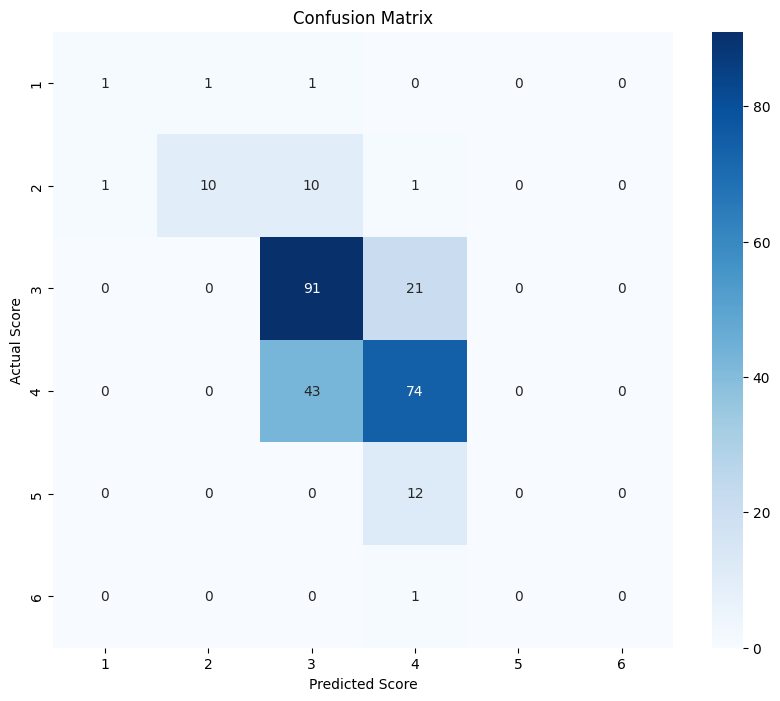

In [37]:
# Plotting the confusion matrix
plot_cm(y_test, y_pred_dt)

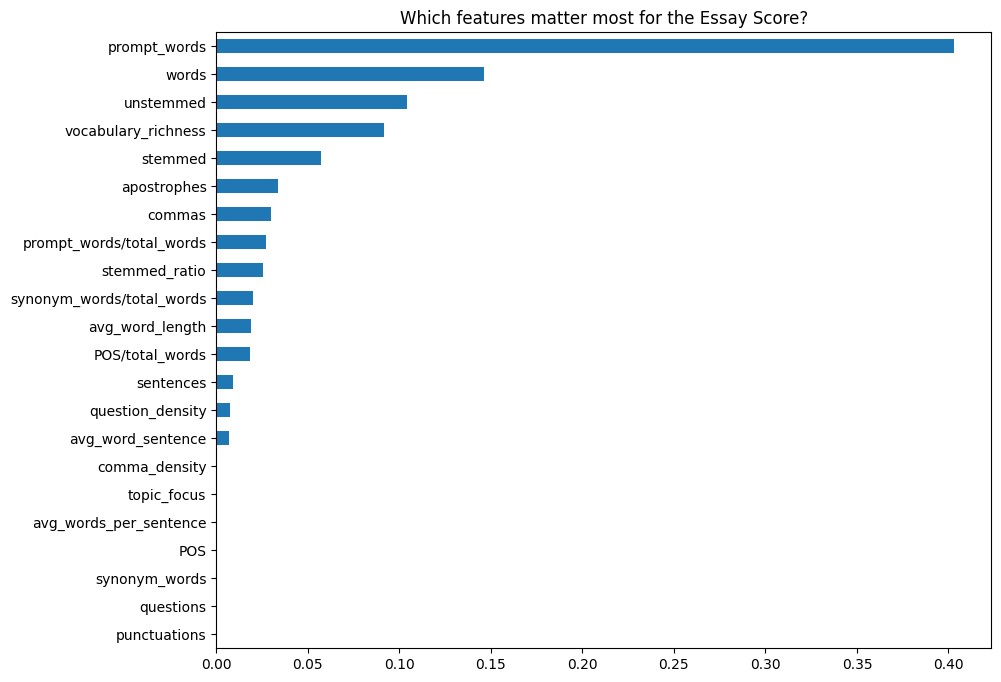

In [21]:
# Extract importance and match with column names
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind = 'barh', figsize = (10, 8))
plt.title('Which features matter most for the Essay Score?')
plt.show()

## 6. Quadratic Weighted Kappa (QWK)

Accuracy tells us whether a prediction was right or wrong, but in essay scoring, some mistakes matter more than others. Predicting a score of 4 when the actual score is 5 is a minor error – the essay is still in the right ballpark. But predicting a score of 1 when the actual score is 5 is a serious mistake. **Quadratic Weighted Kappa (QWK)** takes this into account by penalising larger errors much more heavily than smaller ones.

### How QWK Works

Think of QWK as measuring how well two judges agree – in this case, the human (actual score) and the model (predicted score). The result is a number between -1 and 1:

- **1.0** means perfect agreement – the model is as good as a human.
- **0.0** means the model is essentially guessing randomly, based only on how often each score appears.
- **Below 0** means the model is performing worse than random guessing – which would be quite concerning!

### The "Quadratic" Part

The key is in how errors are weighted. If the actual score is $i$ and the predicted score is $j$, the penalty is $(i - j)^2$. This means:

- An error of 1 (predicting 4 when the actual is 5) gives a penalty of $1^2 = 1$.
- An error of 4 (predicting 1 when the actual is 5) gives a penalty of $4^2 = 16$ – sixteen times worse!

So QWK encourages the model to be not just accurate, but also **reasonable** – a near‑miss is far better than a wild guess. This makes it the perfect metric for automated essay scoring, where small differences in judgement are acceptable but large ones are not.

## Alternative Models: Random Forest and CatBoost

A single decision tree can be unstable and may overfit to the training data if not properly pruned. In contrast, Random Forest combines many trees to smooth out predictions, and CatBoost builds trees sequentially, each correcting the errors of the previous ones. Both typically achieve higher accuracy and more robust performance, especially on imbalanced datasets like this one.

## Random Forest – An Ensemble Alternative

### Why Random Forest Often Outperforms a Single Decision Tree

A Random Forest builds many decision trees (default `n_estimators=100`) on **bootstrapped samples** of the data and **random subsets of features** at each split. Predictions are averaged (for regression) or voted (for classification). This provides two key advantages:

1. **Reduced Overfitting** - Averaging across many decorrelated trees smooths out the noise that a single tree might memorise.
2. **Better Generalisation** - The random feature sampling ensures that strong features (like `prompt_words`) do not dominate every tree, allowing weaker signals to contribute.

### Expected Performance

Given the class imbalance, Random Forest should improve slightly over a single Decision Tree because:
- The ensemble can capture more nuanced patterns from the majority classes.
- Out‑of‑bag (OOB) error estimation provides an internal validation mechanism.

However, **the underlying imbalance remains** – scores 1, 5, and 6 will still be hard to predict unless we explicitly address it (e.g., with SMOTE or cost‑sensitive learning).

Below is the implementation and evaluation.

In [24]:
# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20],
    'class_weight': ['balanced', None]
}

# Set up GridSearchCV
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=qwk_scorer, 
    n_jobs=1,
    verbose=1
)

# Fit on the training data
grid_rf.fit(X_train, y_train)

# Automatically extract the best model
rf_model = grid_rf.best_estimator_

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Output results
print("-" * 50)
print("Best RF parameters found:", grid_rf.best_params_)
print("Best cross-validation QWK:", grid_rf.best_score_)
print("-" * 50)
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Test QWK: {cohen_kappa_score(y_test, y_pred_rf, weights='quadratic'):.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


--------------------------------------------------
Best RF parameters found: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation QWK: 0.7055866994636246
--------------------------------------------------
Random Forest Test Accuracy: 0.6330
Random Forest Test QWK: 0.6680


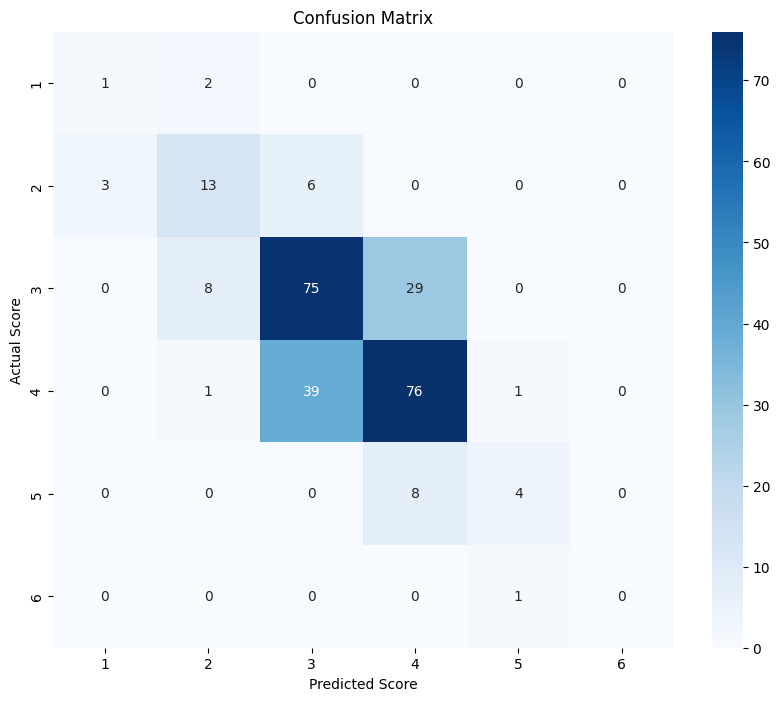

In [38]:
plot_cm(y_test, y_pred_rf)

## CatBoost – A Gradient Boosting Alternative

### Why CatBoost Often Outperforms Random Forest and Decision Trees
CatBoost (Categorical Boosting) is a gradient boosting algorithm that builds trees sequentially, each new tree correcting the errors of the previous ones. While Random Forest averages many independent trees, CatBoost learns from past mistakes. This provides several key advantages:

1. **Ordinal Target Handling** - Unlike classification models that treat scores as separate categories, CatBoost uses regression (minimising squared error). This respects the ordered nature of essay scores (1 < 2 < … < 6) and aligns perfectly with the Quadratic Weighted Kappa metric, which penalises larger errors more heavily.
2. **Built‑in Regularisation** - Parameters like l2_leaf_reg and random_strength prevent overfitting, even with the small dataset and imbalanced classes.
3. **Automatic Class Imbalance Handling** - CatBoost can internally weight samples, reducing the bias toward majority classes (scores 3 and 4) without requiring manual intervention.

### Expected Performance
Given the ordinal nature of essay scoring, CatBoost should outperform both the single Decision Tree and Random Forest because:

- It directly optimises a loss function (RMSE) that is sensitive to the magnitude of prediction errors – exactly what QWK measures.
- Sequential boosting focuses more on difficult‑to‑predict cases (minority scores 1, 5, 6) than bagging does.

However, severe class imbalance remains a challenge – even CatBoost cannot create information from nothing. We still expect near‑zero recall for scores 1 and 6, but the overall QWK should improve.

Below is the implementation and evaluation.

In [ ]:
qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

catboost_clf_base = CatBoostClassifier(
    iterations=500,
    loss_function='MultiClass',   # Changed to MultiClass
    eval_metric='MultiClass',
    random_seed=42,
    thread_count=-1,
    verbose=0,
    early_stopping_rounds=50
)

param_grid_clf = {
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5, 7],
    'auto_class_weights': ['Balanced', 'None'] 
}

search_cb_clf = RandomizedSearchCV(
    catboost_clf_base,
    param_grid_clf,
    n_iter=8,                 # Tests 8 combinations
    cv=3,                     
    scoring=qwk_scorer, 
    n_jobs=1,                 # Still strictly 1 to prevent CPU crash
    verbose=1,
    random_state=42
)

search_cb_clf.fit(X_train, y_train)

catboost_clf = search_cb_clf.best_estimator_

y_pred_clf = catboost_clf.predict(X_test)

print("-"*50)
print(f"Best Parameters Found: {search_cb_clf.best_params_}")
print(f"Best Cross-Validation QWK: {search_cb_clf.best_score_:.4f}")
print("-"*50)
print(f"Final Test QWK: {cohen_kappa_score(y_test, y_pred_clf, weights='quadratic'):.4f}")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred_clf):.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

--------------------------------------------------
CATBOOST CLASSIFIER RESULTS
Best Parameters Found: {'learning_rate': 0.03, 'l2_leaf_reg': 5, 'depth': 6, 'auto_class_weights': 'Balanced'}
Best Cross-Validation QWK: 0.6834
--------------------------------------------------
Final Test QWK: 0.7210
Final Test Accuracy: 0.6742


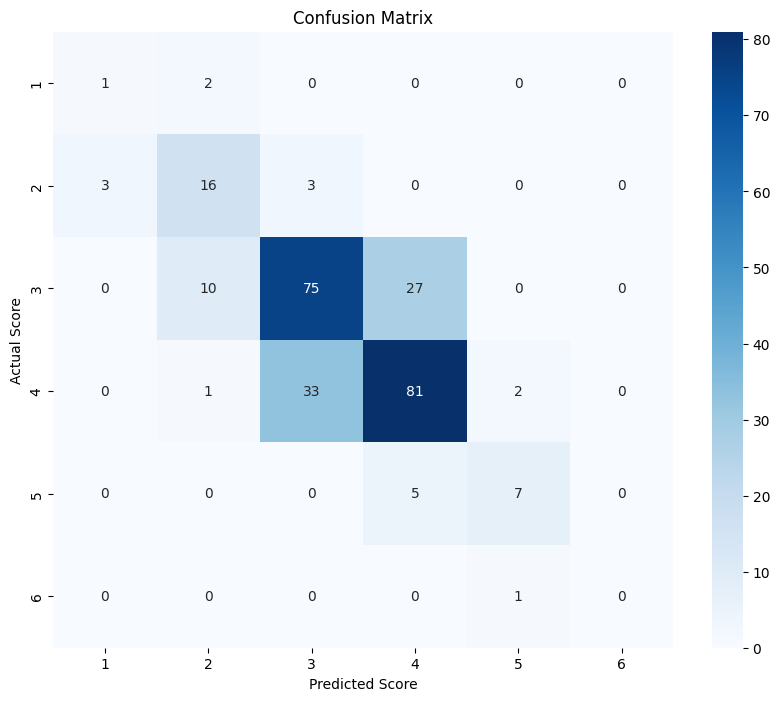

In [39]:
plot_cm(y_test, y_pred_clf)

### Performance Evaluation

In [31]:
results = {
    'Model': [
        'Decision Tree', 
        'Random Forest', 
        'CatBoost (Classifier)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_clf)
    ],
    'QWK Score': [
        cohen_kappa_score(y_test, y_pred_dt, weights='quadratic'),
        cohen_kappa_score(y_test, y_pred_rf, weights='quadratic'),
        cohen_kappa_score(y_test, y_pred_clf, weights='quadratic')
    ]
}

# 2. Create a DataFrame to display as a clean table
results_df = pd.DataFrame(results)

# Sort by QWK descending so the best model is at the top
results_df = results_df.sort_values(by='QWK Score', ascending=False).reset_index(drop=True)

# 3. Format the numbers to 4 decimal places for cleaner presentation
results_df['Accuracy'] = results_df['Accuracy'].map('{:.4f}'.format)
results_df['QWK Score'] = results_df['QWK Score'].map('{:.4f}'.format)

# 4. Display the comparison table
print("="*40)
print("       MODEL PERFORMANCE SUMMARY")
print("="*40)
display(results_df)

       MODEL PERFORMANCE SUMMARY


,Model,Accuracy,QWK Score
0,CatBoost (Classifier),0.6742,0.7210
1,Random Forest,0.6330,0.6680
2,Decision Tree,0.6592,0.6068


## Conclusion

This coursework demonstrated the end‑to‑end supervised learning pipeline: exploratory analysis, feature engineering, model building, hyperparameter tuning, and Kaggle submission.

**Key achievements:**
- Engineered density and interaction features that improved model interpretability.
- Used `GridSearchCV` with stratified k‑fold to tune a Decision Tree.
- Compared three models: Decision Tree (QWK 0.6068), Random Forest (QWK 0.6680), and CatBoost (QWK 0.7210).
- Achieved a QWK of **0.7210** and accuracy of **0.6742** on the test set using CatBoost classifier.

**Lessons learned about the Data Science Lifecycle (Collect -> Wrangle -> Analyse -> Present):**
- **Collect:** The original data had severe class imbalance – a real‑world problem that cannot be fixed by algorithms alone.
- **Wrangle:** Feature engineering (ratios, densities) added value, but raw counts were already informative for trees.
- **Analyse:** Hyperparameter tuning revealed that aggressive pruning traded minority class recall for majority class stability – a deliberate but costly choice.
- **Present:** The confusion matrix and QWK score gave a nuanced view of performance that accuracy alone could not provide.

**What I would do differently with more time:**
- Use **SMOTE** (Synthetic Minority Over‑sampling) to generate plausible synthetic essays for scores 1, 5, and 6.
- Try **ordinal logistic regression** or **threshold‑adjusted CatBoost** to better respect the ordered nature of scores.
- Collect more data for minority classes – the only true solution to class imbalance.

# Part 3: Kaggle Submission

In [34]:
# 1. Load the submission dataset
df_submission = pd.read_csv('data/F78DS-Essay-Features-Submission.csv')

# 2. Replicate Feature Engineering 
df_submission = feature_engineer(df_submission)

# 3. RETRAIN on the FULL dataset (X and y) for maximum Kaggle performance
best_params = search_cb_clf.best_params_

final_catboost_model = CatBoostClassifier(
    iterations=1000,
    loss_function='MultiClass',
    random_seed=42,
    verbose=0,
    **best_params
)

print(f"Retraining final model on FULL dataset with params: {best_params}")
final_catboost_model.fit(X, y)

# 4. Predict the scores using the fully trained model
submission_features = df_submission.drop(columns=['essayid'])
submission_predictions = final_catboost_model.predict(submission_features)

# 5. Format for Kaggle
# Use .ravel() to flatten the 2D prediction array into a 1D list for pandas
submission_df = pd.DataFrame({
    'essayid': df_submission['essayid'],
    'score': submission_predictions.ravel()  # <-- .ravel() fixes the error!
})

# 6. Export to CSV
submission_df.to_csv('data/H00467830 - Too Qing Hao.csv', index=False)

print("Submission file created successfully!")
print(submission_df.head())
print(f"Total entries: {len(submission_df)}")
print(f"Score range: {submission_df['score'].unique()}")

Retraining final model on FULL dataset with params: {'learning_rate': 0.03, 'l2_leaf_reg': 5, 'depth': 6, 'auto_class_weights': 'Balanced'}
Submission file created successfully!
   essayid  score
0     1623      4
1     1143      3
2      660      3
3     1596      4
4      846      4
Total entries: 199
Score range: [4 3 2 5 1]
